# Notebook 2 — Shared Molecular Patterns Using Canonical Correlation Analysis

**Workshop:** AI-Driven Multi-Omics Analysis  
**Use case:** Shared molecular patterns  
**Method:** Canonical Correlation Analysis (CCA)  
**Dataset:** TCGA-BRCA frozen cohort (617 patients)  
**Modalities:** RNA-seq (617 × 1,000 genes) and miRNA (617 × 300 miRNAs)  
**Runtime:** seconds to minutes on CPU

---

### Biological question

*Do the RNA-seq and miRNA expression profiles of TCGA-BRCA patients contain a shared molecular signal — patterns that appear in both molecular layers simultaneously?*

### What is CCA?

Canonical Correlation Analysis (CCA) is a classical multivariate statistical method that finds **pairs of linear combinations** — one from each modality — that are maximally correlated with each other. These pairs are called *canonical variates* and the correlation between them is the *canonical correlation*.

Unlike simple correlation between individual genes and miRNAs, CCA finds **multi-feature axes** that capture the overall shared structure between two high-dimensional datasets.

### Relation to AI-driven multi-omics

CCA is a **statistical representation-learning method** — it transforms two heterogeneous molecular datasets into shared low-dimensional representations without using any clinical labels. It demonstrates that integration can begin with principled statistical tools before more complex neural network models are applied.

> ⚠️ PAM50 subtype labels are **not used** during CCA. They appear only at the end as an external biological reference.

---
## Part 1 — Imports, Paths, and Seeds

In [1]:
import time
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(".").resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Project root  : {PROJECT_DIR}")
print(f"Processed dir : {PROCESSED_DIR}")
print(f"Random seed   : {SEED}")

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"    : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.size"     : 11,
})

Project root  : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop
Processed dir : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed
Random seed   : 42


---
## Part 2 — Load the Frozen TCGA-BRCA Data

We load the pre-processed matrices generated in Notebook 1.  
**Raw TCGA files are not reloaded.** All matrices come from `data/processed/`.

In [2]:
t_start = time.time()

# ── Load processed matrices ────────────────────────────────────────────────────
rna_path   = PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv"
mirna_path = PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv"
cohort_path = PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv"

for p in [rna_path, mirna_path, cohort_path]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required file not found: {p}\n"
            "Please run Notebook 1 first to generate the processed matrices."
        )

rna_df    = pd.read_csv(rna_path,   sep="\t", index_col=0)
mirna_df  = pd.read_csv(mirna_path, sep="\t", index_col=0)
cohort_df = pd.read_csv(cohort_path, sep="\t", index_col="sample_id")

print("Loaded processed matrices:")
print(f"  RNA-seq  : {rna_df.shape[0]} samples × {rna_df.shape[1]} genes")
print(f"  miRNA    : {mirna_df.shape[0]} samples × {mirna_df.shape[1]} miRNAs")
print(f"  Cohort   : {cohort_df.shape[0]} samples")

# ── Integrity checks ──────────────────────────────────────────────────────────
assert list(rna_df.index) == list(mirna_df.index), \
    "Sample order mismatch between RNA and miRNA matrices"
assert rna_df.isnull().sum().sum()   == 0, "Missing values in RNA matrix"
assert mirna_df.isnull().sum().sum() == 0, "Missing values in miRNA matrix"
assert rna_df.columns.nunique()   == rna_df.shape[1],   "Duplicate RNA features"
assert mirna_df.columns.nunique() == mirna_df.shape[1], "Duplicate miRNA features"

print("\n✅ All integrity checks passed:")
print(f"  Identical sample ordering across both modalities")
print(f"  Zero missing values in RNA-seq")
print(f"  Zero missing values in miRNA")
print(f"  No duplicate feature IDs")

Loaded processed matrices:
  RNA-seq  : 617 samples × 1000 genes
  miRNA    : 617 samples × 300 miRNAs
  Cohort   : 617 samples

✅ All integrity checks passed:
  Identical sample ordering across both modalities
  Zero missing values in RNA-seq
  Zero missing values in miRNA
  No duplicate feature IDs


---
## Part 3 — Statistical Feature Selection for CCA

> **Workshop note:** To keep this demonstration computationally lightweight, we use variance-based feature selection to reduce the RNA and miRNA matrices before CCA. This is a dimensionality-reduction step for presentation purposes — it is **not** a claim that these are the biologically optimal features.

CCA on the full 1,000 × 300 matrices would be numerically unstable: when the number of features approaches or exceeds the number of samples, the CCA solution becomes degenerate. Reducing to a small, high-variance subset avoids this and makes the results easier to interpret.

| Modality | Before | After | Method |
|---|---|---|---|
| RNA-seq | 1,000 genes | 100 genes | Top 100 by variance |
| miRNA | 300 miRNAs | 30 miRNAs | Top 30 by variance |

In [3]:
N_RNA_CCA   = 100
N_MIRNA_CCA = 30

# Variance-based selection — no labels used
top_rna_genes  = rna_df.var(axis=0).nlargest(N_RNA_CCA).index
top_mirna_ids  = mirna_df.var(axis=0).nlargest(N_MIRNA_CCA).index

X_raw = rna_df[top_rna_genes].values.astype(float)    # (617, 100)
Y_raw = mirna_df[top_mirna_ids].values.astype(float)   # (617, 30)

sample_ids = rna_df.index.tolist()

print(f"RNA-seq  after feature selection: {X_raw.shape}  ({N_RNA_CCA} genes)")
print(f"miRNA    after feature selection: {Y_raw.shape}  ({N_MIRNA_CCA} miRNAs)")
print()
print(f"Top 5 RNA genes selected : {list(top_rna_genes[:5])}")
print(f"Top 5 miRNA IDs selected : {list(top_mirna_ids[:5])}")

RNA-seq  after feature selection: (617, 100)  (100 genes)
miRNA    after feature selection: (617, 30)  (30 miRNAs)

Top 5 RNA genes selected : ['CLEC3A', 'CPB1', 'SCGB2A2', 'SCGB1D2', 'TFF1']
Top 5 miRNA IDs selected : ['MIMAT0005923', 'MIMAT0000454', 'MIMAT0000226', 'MIMAT0000266', 'MIMAT0000262']


---
## Part 4 — Standardisation

CCA seeks linear combinations of features that **maximise correlation** between the two datasets. If features have very different scales (e.g., a gene with expression ranging 0–15 vs a miRNA ranging 0–1), the algorithm will be dominated by the larger-scale variables regardless of their biological relevance.

**StandardScaler** centres each feature to mean 0 and scales to unit variance. This ensures all features contribute on an equal numerical footing.

> **No train/test split** is applied here. This notebook is about **exploratory discovery** of shared molecular structure, not predictive modelling. There is no held-out test set to evaluate.

X (RNA-seq, standardised) : shape=(617, 100)  mean=0.0000  std=1.0000
Y (miRNA,   standardised) : shape=(617, 30)  mean=0.0000  std=1.0000


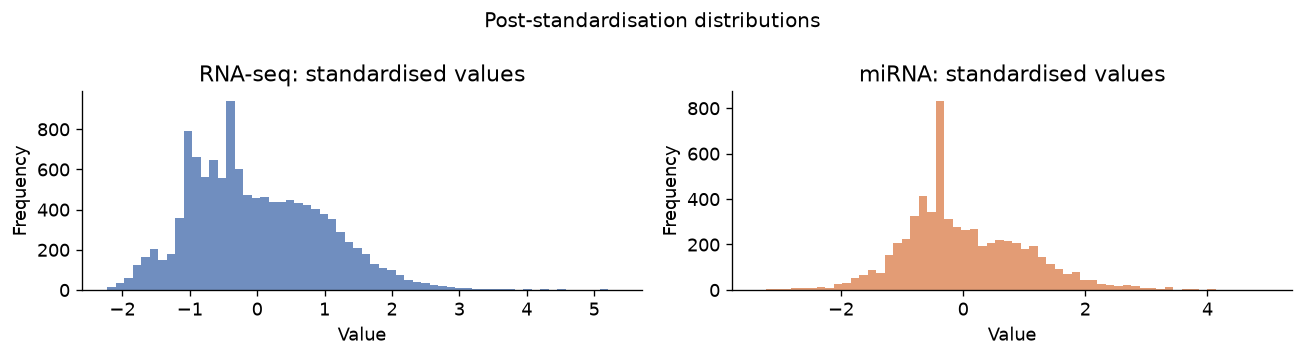

In [4]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X = scaler_X.fit_transform(X_raw)   # (617, 100)
Y = scaler_Y.fit_transform(Y_raw)   # (617, 30)

print(f"X (RNA-seq, standardised) : shape={X.shape}  mean={X.mean():.4f}  std={X.std():.4f}")
print(f"Y (miRNA,   standardised) : shape={Y.shape}  mean={Y.mean():.4f}  std={Y.std():.4f}")

# Quick distribution check
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(X.ravel()[::5], bins=60, color="#4C72B0", alpha=0.8)
axes[0].set_title("RNA-seq: standardised values"); axes[0].set_xlabel("Value")
axes[1].hist(Y.ravel()[::3], bins=60, color="#DD8452", alpha=0.8)
axes[1].set_title("miRNA: standardised values"); axes[1].set_xlabel("Value")
for ax in axes:
    ax.set_ylabel("Frequency")
plt.suptitle("Post-standardisation distributions", fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 5 — Canonical Correlation Analysis

We fit CCA with **5 canonical components** between the 617 × 100 RNA matrix and the 617 × 30 miRNA matrix.

**What CCA computes:**

$$\max_{w_X, w_Y} \; \text{corr}(X w_X,\; Y w_Y)$$

Each component pair $(w_X^{(k)}, w_Y^{(k)})$ defines a linear combination of RNA features and a linear combination of miRNA features such that the resulting *scores* are maximally correlated — subject to being orthogonal to all previous components.

- $X_c = X \cdot W_X$ → RNA canonical variates (617 × 5)  
- $Y_c = Y \cdot W_Y$ → miRNA canonical variates (617 × 5)

In [5]:
N_COMPONENTS = 5

t_cca = time.time()
cca = CCA(n_components=N_COMPONENTS, max_iter=1000)
cca.fit(X, Y)
X_c, Y_c = cca.transform(X, Y)   # canonical variates
cca_time = time.time() - t_cca

print(f"CCA fitted in {cca_time:.2f} seconds")
print(f"  RNA canonical variates  (X_c): {X_c.shape}")
print(f"  miRNA canonical variates (Y_c): {Y_c.shape}")

CCA fitted in 0.24 seconds
  RNA canonical variates  (X_c): (617, 5)
  miRNA canonical variates (Y_c): (617, 5)


---
## Part 6 — Canonical Correlations

For each of the 5 component pairs, we compute the Pearson correlation between the RNA and miRNA canonical variates.

The first canonical correlation is the **strongest** shared linear pattern between the two datasets; each subsequent component captures the next-strongest pattern that is orthogonal to all previous ones.

Canonical correlations (RNA ↔ miRNA):
                     Pearson correlation
Canonical component                     
CV1                               0.9519
CV2                               0.8746
CV3                               0.8157
CV4                               0.7851
CV5                               0.7480


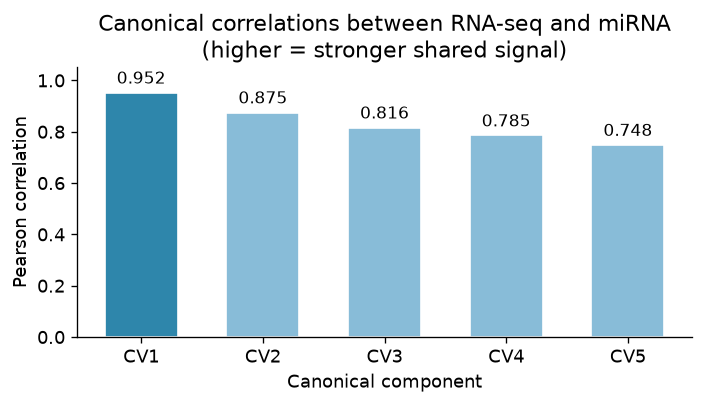

In [6]:
canonical_corrs = []
for i in range(N_COMPONENTS):
    r, p = pearsonr(X_c[:, i], Y_c[:, i])
    canonical_corrs.append(r)

corr_df = pd.DataFrame({
    "Canonical component": [f"CV{i+1}" for i in range(N_COMPONENTS)],
    "Pearson correlation" : [round(r, 4) for r in canonical_corrs],
})
corr_df = corr_df.set_index("Canonical component")

print("Canonical correlations (RNA ↔ miRNA):")
print(corr_df.to_string())

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["#2E86AB" if i == 0 else "#88BCD8" for i in range(N_COMPONENTS)]
ax.bar(corr_df.index, corr_df["Pearson correlation"], color=colors, edgecolor="white", width=0.6)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Canonical component"); ax.set_ylabel("Pearson correlation")
ax.set_title("Canonical correlations between RNA-seq and miRNA\n(higher = stronger shared signal)")
for i, r in enumerate(canonical_corrs):
    ax.text(i, r + 0.02, f"{r:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

### Interpretation and limitations

- **CCA identifies linear combinations of RNA and miRNA measurements that are maximally correlated across patients.** The canonical correlations reflect how well a weighted combination of genes and a weighted combination of miRNAs can agree on a common axis of patient variation — not how strongly any individual gene is linked to any individual miRNA.

- **The high canonical correlations indicate strong shared structure in this particular cohort, but they should not be interpreted as causal biological relationships.** A high correlation between two molecular measurements does not establish that one regulates the other. Independent experimental evidence is required to move from statistical association to biological mechanism.

- **Because feature selection and CCA were performed on the same cohort without an independent validation cohort, these correlations are exploratory and may be optimistic.** In a production analysis, feature selection statistics would be estimated on a training split and the canonical correlations evaluated on a held-out test set.

- **The top-loading genes and miRNAs are candidates for biological interpretation, not proof of regulatory interactions.** They represent features that contribute strongly to the mathematical canonical axis and are therefore worth examining in the context of known biology — but the CCA model itself makes no claims about the direction or mechanism of any relationship.

---
## Part 7 — Visualise the First Shared Molecular Pattern

The scatter plot below is the **central visualisation** of this notebook.

> Each point represents one patient. The CCA transformation creates one score from the RNA measurements (`RNA CV1`) and one score from the miRNA measurements (`miRNA CV1`). A strong Pearson correlation between these two scores means that the two molecular modalities contain a **shared pattern across patients** — patients who rank high on the RNA axis tend to rank high on the miRNA axis too.

This shared axis is the linear combination of RNA genes and miRNA species that best captures what both layers are "saying" simultaneously.

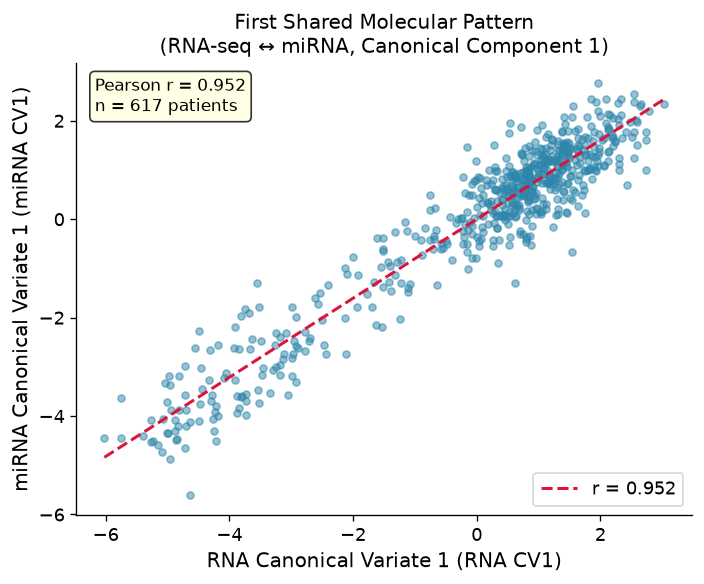

Canonical correlation 1 (r) = 0.9519


In [7]:
r1 = canonical_corrs[0]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_c[:, 0], Y_c[:, 0], s=18, alpha=0.5, color="#2E86AB", rasterized=True)

# Trend line
m, b = np.polyfit(X_c[:, 0], Y_c[:, 0], 1)
xs = np.linspace(X_c[:, 0].min(), X_c[:, 0].max(), 100)
ax.plot(xs, m * xs + b, color="crimson", linewidth=1.8, linestyle="--", label=f"r = {r1:.3f}")

ax.set_xlabel("RNA Canonical Variate 1 (RNA CV1)", fontsize=12)
ax.set_ylabel("miRNA Canonical Variate 1 (miRNA CV1)", fontsize=12)
ax.set_title("First Shared Molecular Pattern\n(RNA-seq ↔ miRNA, Canonical Component 1)",
             fontsize=12)
ax.legend(fontsize=11)
ax.text(0.03, 0.97, f"Pearson r = {r1:.3f}\nn = {len(X_c)} patients",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_CCA_CV1_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Canonical correlation 1 (r) = {r1:.4f}")

---
## Part 8 — Top Contributing Molecular Features

Each canonical component is a weighted linear combination of features. The **CCA coefficients** (loadings) tell us which genes and miRNAs contribute most strongly to the first shared axis.

> ⚠️ **Important caveat:** High-loading features are strongly associated with the mathematical canonical axis. They are **candidates** for biological investigation, but CCA alone does not establish causal or regulatory relationships between RNA and miRNA. Independent experimental validation is required to interpret these associations biologically.

Top 10 RNA features contributing to Canonical Axis 1:
         Loading
Gene            
TFF3      0.3375
C1orf64   0.2832
AGR3      0.2747
A2ML1    -0.2150
KRT81    -0.1971
MUC16    -0.1947
STAC2     0.1776
CRABP1   -0.1732
CST9      0.1625
PRAME    -0.1560

Top 10 miRNA features contributing to Canonical Axis 1:
              Loading
miRNA                
MIMAT0003242  -0.3969
MIMAT0004929   0.3884
MIMAT0000758  -0.3857
MIMAT0004784  -0.3363
MIMAT0000267  -0.2766
MIMAT0000434  -0.2549
MIMAT0000728   0.2240
MIMAT0017985   0.2226
MIMAT0004809   0.2146
MIMAT0026480   0.1647


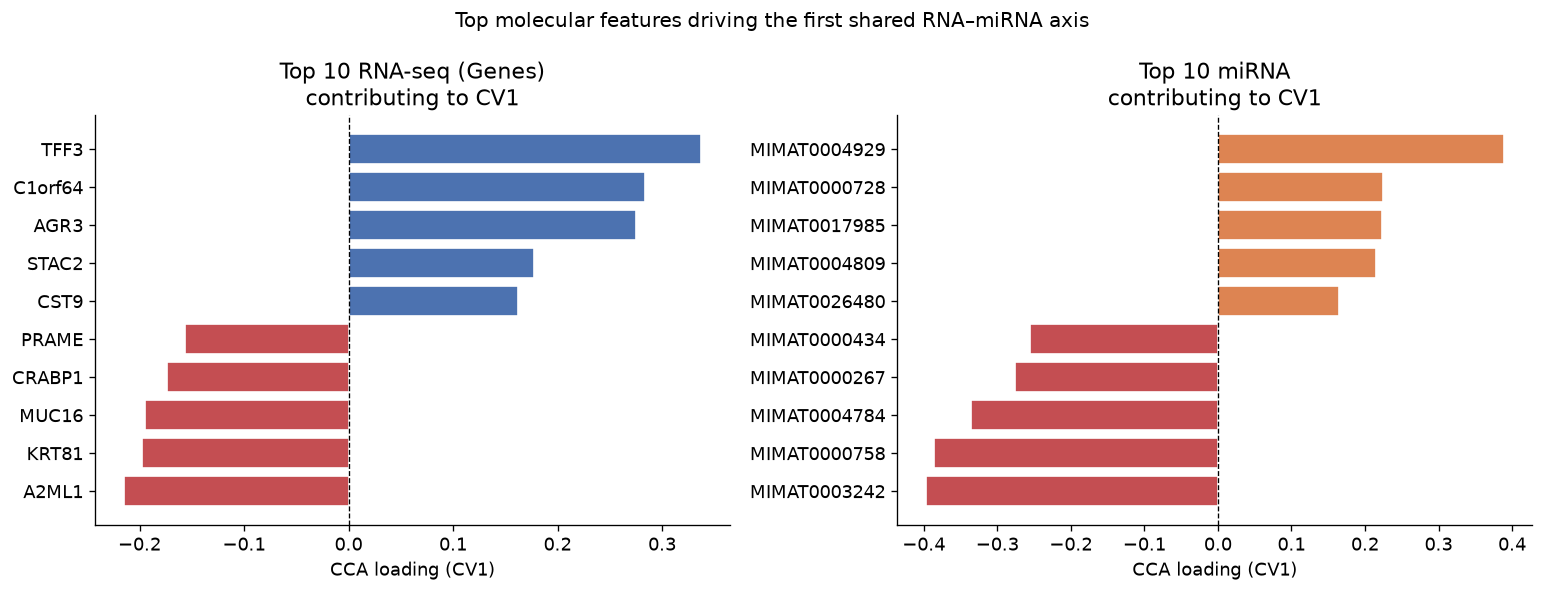

In [8]:
N_TOP = 10

# CCA coefficients: x_rotations_ = loadings for X (RNA), y_rotations_ = loadings for Y (miRNA)
rna_loadings_cv1   = cca.x_rotations_[:, 0]   # length = N_RNA_CCA
mirna_loadings_cv1 = cca.y_rotations_[:, 0]   # length = N_MIRNA_CCA

# Top RNA features by |loading|
rna_load_df = pd.DataFrame({
    "Gene"   : top_rna_genes,
    "Loading": rna_loadings_cv1,
}).set_index("Gene")
rna_top = rna_load_df["Loading"].abs().nlargest(N_TOP).index
rna_top_df = rna_load_df.loc[rna_top].sort_values("Loading", key=abs, ascending=False)

# Top miRNA features by |loading|
mirna_load_df = pd.DataFrame({
    "miRNA"  : top_mirna_ids,
    "Loading": mirna_loadings_cv1,
}).set_index("miRNA")
mirna_top = mirna_load_df["Loading"].abs().nlargest(N_TOP).index
mirna_top_df = mirna_load_df.loc[mirna_top].sort_values("Loading", key=abs, ascending=False)

print("Top 10 RNA features contributing to Canonical Axis 1:")
print(rna_top_df.round(4).to_string())
print()
print("Top 10 miRNA features contributing to Canonical Axis 1:")
print(mirna_top_df.round(4).to_string())

# ── Horizontal bar charts ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, color, label in [
    (axes[0], rna_top_df,   "#4C72B0", "RNA-seq (Genes)"),
    (axes[1], mirna_top_df, "#DD8452", "miRNA"),
]:
    sorted_df = df.sort_values("Loading")
    bar_colors = [color if v >= 0 else "#C44E52" for v in sorted_df["Loading"]]
    ax.barh(sorted_df.index, sorted_df["Loading"], color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("CCA loading (CV1)"); ax.set_title(f"Top {N_TOP} {label}\ncontributing to CV1")

plt.suptitle("Top molecular features driving the first shared RNA–miRNA axis",
             fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_CCA_loadings_CV1.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 9 — Optional: PAM50 Interpretation

> PAM50 subtype labels are introduced here **only as an external biological reference**. The CCA model was fitted without knowledge of these labels. Any structure visible in the plot below is an emergent property of the molecular data, not a result of supervised optimisation.

We colour the CV1 scatter plot by PAM50 subtype to ask: *does the first shared RNA–miRNA axis align with known molecular subtypes?*

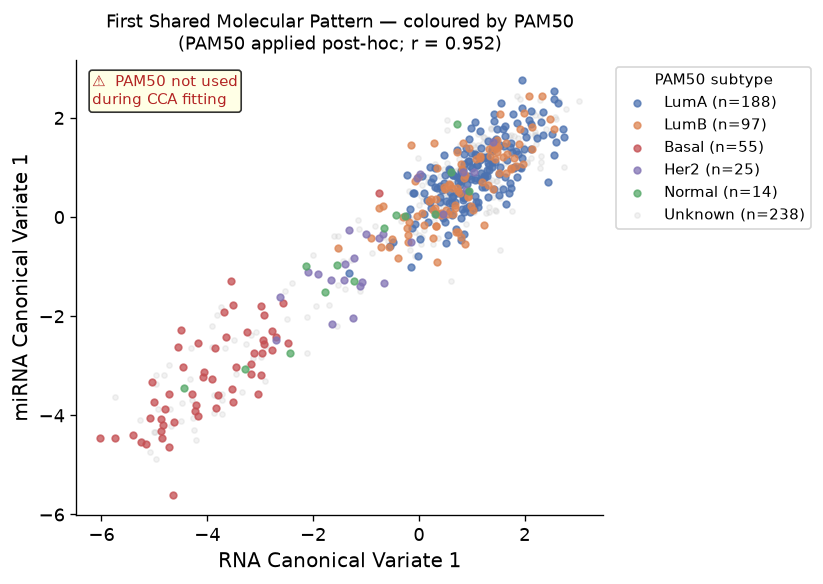

In [9]:
SUBTYPE_ORDER  = ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]
SUBTYPE_COLORS = {
    "LumA"   : "#4C72B0", "LumB"   : "#DD8452",
    "Basal"  : "#C44E52", "Her2"   : "#8172B3",
    "Normal" : "#55A868", "Unknown": "#CCCCCC",
}

pam50_labels = cohort_df["PAM50_subtype"].reindex(sample_ids).fillna("Unknown")

fig, ax = plt.subplots(figsize=(7, 5))
for st in SUBTYPE_ORDER:
    mask = pam50_labels.values == st
    if mask.sum() == 0:
        continue
    alpha = 0.25 if st == "Unknown" else 0.75
    size  = 10   if st == "Unknown" else 16
    ax.scatter(X_c[mask, 0], Y_c[mask, 0],
               s=size, color=SUBTYPE_COLORS[st], alpha=alpha,
               label=f"{st} (n={mask.sum()})", rasterized=True,
               zorder=1 if st == "Unknown" else 2)

ax.set_xlabel("RNA Canonical Variate 1", fontsize=12)
ax.set_ylabel("miRNA Canonical Variate 1", fontsize=12)
ax.set_title(f"First Shared Molecular Pattern — coloured by PAM50\n"
             f"(PAM50 applied post-hoc; r = {r1:.3f})", fontsize=11)
ax.legend(title="PAM50 subtype", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=9, title_fontsize=9)
ax.text(0.03, 0.97, "⚠️  PAM50 not used\nduring CCA fitting",
        transform=ax.transAxes, va="top", fontsize=9, color="firebrick",
        bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", alpha=0.8))
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_CCA_CV1_PAM50.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 10 — Save Results

Save the canonical variates, feature loadings, and a metadata JSON for reproducibility.

In [10]:
from datetime import date

# ── CCA scores (canonical variates) ───────────────────────────────────────────
scores_cols = (
    [f"RNA_CV{i+1}"   for i in range(N_COMPONENTS)] +
    [f"miRNA_CV{i+1}" for i in range(N_COMPONENTS)]
)
scores_arr = np.hstack([X_c, Y_c])
scores_df  = pd.DataFrame(scores_arr, index=sample_ids, columns=scores_cols)
scores_df.index.name = "sample_id"

SCORES_PATH = PROCESSED_DIR / "TCGA_BRCA_CCA_scores.tsv"
scores_df.to_csv(SCORES_PATH, sep="\t", float_format="%.6f")
print(f"✅ {SCORES_PATH.name}  ({SCORES_PATH.stat().st_size/1e3:.1f} KB)  shape={scores_df.shape}")

# ── CCA loadings ───────────────────────────────────────────────────────────────
loading_rows = []
for comp in range(N_COMPONENTS):
    for feat, load in zip(top_rna_genes, cca.x_rotations_[:, comp]):
        loading_rows.append({"modality": "RNA-seq", "feature": feat,
                              "canonical_component": f"CV{comp+1}", "loading": round(float(load), 6)})
    for feat, load in zip(top_mirna_ids, cca.y_rotations_[:, comp]):
        loading_rows.append({"modality": "miRNA", "feature": feat,
                              "canonical_component": f"CV{comp+1}", "loading": round(float(load), 6)})

loadings_df = pd.DataFrame(loading_rows)
LOADINGS_PATH = PROCESSED_DIR / "TCGA_BRCA_CCA_loadings.tsv"
loadings_df.to_csv(LOADINGS_PATH, sep="\t", index=False)
print(f"✅ {LOADINGS_PATH.name}  ({LOADINGS_PATH.stat().st_size/1e3:.1f} KB)  rows={len(loadings_df)}")

# ── CCA metadata JSON ─────────────────────────────────────────────────────────
total_time = time.time() - t_start
cca_results = {
    "created"                 : str(date.today()),
    "n_samples"               : len(sample_ids),
    "rna_feature_count"       : N_RNA_CCA,
    "mirna_feature_count"     : N_MIRNA_CCA,
    "n_canonical_components"  : N_COMPONENTS,
    "canonical_correlations"  : {f"CV{i+1}": round(r, 6) for i, r in enumerate(canonical_corrs)},
    "feature_selection_criterion": f"Top {N_RNA_CCA} RNA genes and top {N_MIRNA_CCA} miRNAs by variance",
    "standardisation"         : "StandardScaler applied independently to each modality",
    "random_seed"             : SEED,
    "no_train_test_split"     : True,
    "pam50_used_in_cca"       : False,
    "total_runtime_seconds"   : round(total_time, 1),
    "output_files"            : {
        "scores"   : "TCGA_BRCA_CCA_scores.tsv",
        "loadings" : "TCGA_BRCA_CCA_loadings.tsv",
        "figures"  : ["TCGA_BRCA_CCA_CV1_scatter.png",
                      "TCGA_BRCA_CCA_loadings_CV1.png",
                      "TCGA_BRCA_CCA_CV1_PAM50.png"],
    },
}

CCA_META_PATH = PROCESSED_DIR / "TCGA_BRCA_CCA_results.json"
with open(CCA_META_PATH, "w") as fh:
    json.dump(cca_results, fh, indent=2)
print(f"✅ {CCA_META_PATH.name}  ({CCA_META_PATH.stat().st_size/1e3:.1f} KB)")

print(f"\nTotal notebook runtime: {total_time:.1f} seconds")

✅ TCGA_BRCA_CCA_scores.tsv  (69.0 KB)  shape=(617, 10)
✅ TCGA_BRCA_CCA_loadings.tsv  (19.3 KB)  rows=650
✅ TCGA_BRCA_CCA_results.json  (0.8 KB)

Total notebook runtime: 59.6 seconds


---
## Why CCA is Useful in AI-Driven Multi-Omics Analysis

1. **Multi-omics data are heterogeneous.** RNA-seq, miRNA, and methylation measure different molecular phenomena on incompatible scales. Treating them as a single flat feature vector ignores their fundamentally different statistical properties.

2. **Simple concatenation does not identify relationships between modalities.** A model trained on a concatenated matrix can find patterns within each modality, but it does not explicitly find patterns that are *shared between* two distinct molecular layers.

3. **CCA searches for maximally correlated multi-feature combinations across two modalities.** Rather than comparing one gene to one miRNA, CCA finds the linear combinations of genes and miRNAs that move together across patients.

4. **Canonical variates provide a shared representation of molecular variation.** These lower-dimensional scores capture cross-modal structure and can be used as interpretable features for downstream analyses.

5. **CCA is an example of representation learning using statistical structure.** It transforms raw, high-dimensional, heterogeneous data into a compact, interpretable, shared representation — without using a neural network.

> **Statistical methods provide the mathematical foundation for identifying structure in high-dimensional biological data. AI models can subsequently build on these representations to learn more complex nonlinear patterns.**  
>
> In this workshop, CCA (Notebook 2) and the VAE (Notebook 1) represent two complementary approaches to the same problem: learning a shared low-dimensional structure from multi-omics data. CCA is linear and interpretable; the VAE is nonlinear and can capture more complex dependencies. Together they illustrate the spectrum from classical statistics to modern deep learning in multi-omics integration.

---
## Notebook 2 — Take-home Message

```
TCGA-BRCA (617 patients)
    ↓
RNA-seq (617 × 1,000)    +    miRNA (617 × 300)
    ↓
Variance-based feature selection
  RNA: 100 genes  |  miRNA: 30 miRNAs
    ↓
Per-modality StandardScaler
    ↓
Canonical Correlation Analysis (5 components)
    ↓
Shared canonical axes (canonical variates)
    ↓
Rank features by CCA loadings
    ↓
Biological interpretation candidates
```

- **CCA identifies shared molecular patterns** by finding linear combinations of RNA features and miRNA features that are maximally correlated across patients.

- **The first canonical correlation** quantifies the strength of the strongest shared signal between the two molecular layers.

- **CCA loadings reveal which features drive the shared axis**, providing interpretable candidates for downstream biological investigation.

- **PAM50 structure is visible post-hoc**, demonstrating that the shared RNA–miRNA signal captures biologically meaningful variation without using any subtype labels.

- **CCA demonstrates that multi-omics integration does not necessarily require a deep neural network.** Statistical representation-learning methods can reveal relationships between molecular layers and provide interpretable inputs or hypotheses for more advanced AI models.